# Chemprop

Kai Zhang, The University of Texas at Tyler

__References:__


GitHub repo https://github.com/chemprop/chemprop

Documentation https://chemprop.readthedocs.io/en/main/

App https://chemprop.com/


## 1. Installation

As of 2026.10, chemprop's dependency on Python version and numpy version can be tricky. It is better to use the recommended `conda` system to create a customized virtual environment. (Also check another notebook `0_intro_to_Python.ipynb`)

Install conda first if not done yet,
```
cd ~/Downloads
wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
bash Miniconda3-latest-Linux-x86_64.sh
```
press some `Enter` and `yes`, which should put conda at
```
/home/your_username/miniconda3
```
Enable conda for the first time after installation
```
source ~/.bashrc
```
(or do it manually if not loaded on the terminal)
```
conda activate
```



Create a dedicated virtual environment for chemprop with a particular Python version, enable it and install chemprop
```
conda create -n chemprop python=3.11
conda activate chemprop
pip install chemprop
```
you may want to install Jupyter under this virtual environment as well (`pip install Jupyter`).

## 2. (Optional) Upgrade Nvidia GPU driver

In case Nvidia GPU driver is not compatible with PyTorch

```
nvidia-smi
sudo ubuntu-drivers list                  # check current available drivers
sudo apt install nvidia-driver-580-open   # install the proper version, say 580-open
sudo reboot
```

In [1]:
# check python version
!which python
!python --version

# show where chemprop package is installed
!pip show chemprop

import numpy as np
print('numpy version:', np.__version__)

import chemprop
print('chemprop version:', chemprop.__version__) # the latest version should be 2.x

import torch
print('PyTorch version:', torch.__version__)
print('CUDA build:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())

# check GPU compatibility, might need to upgrade Nvidia driver for PyTorch
print('GPU:', torch.cuda.get_device_name(0))
print('Capability:', torch.cuda.get_device_capability(0))

/home/tylerdell2/miniconda3/envs/.chemprop/bin/python
Python 3.12.15
Name: chemprop
Version: 2.3.1
Summary: Molecular Property Prediction with Message Passing Neural Networks
Home-page: 
Author: 
Author-email: "The Chemprop Development Team (see LICENSE.txt)" <chemprop@mit.edu>
License: MIT
Location: /home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-packages
Requires: astartes, ConfigArgParse, cuik_molmaker_pin, descriptastorus, lightning, myerson, numpy, pandas, rdkit, rich, scikit-learn, scipy, torch
Required-by: 
numpy version: 2.5.3
chemprop version: 2.3.1
PyTorch version: 2.14.1+cu130
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
Capability: (8, 9)


## 3. Run chemprop on Jupyter notebook for learning purpose

Let's first work through a simplest regression task on Jupyter notebook, step by step. Ultimately, it is more convenient to run chemprop in command line.

__References:__

https://chemprop.readthedocs.io/en/main/training.html

https://github.com/chemprop/chemprop-workshop-acs-fall2023/blob/main/chemprop_colab_demo_acs_fall2023.ipynb

Some commonly used chemprop Python modules are

* `chemprop.data`:
* `chemprop.featurizers`:
* `chemprop.models`:
* `chemprop.nn`:

See their tutorials at https://chemprop.readthedocs.io/en/main/tutorial/python/index.html .

You can also check the definition of a module or a function by, e.g.
```python
help(data)
help(data.make_split_indices)
```

In [2]:
# load certain Python packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from rdkit import Chem

In [3]:
# load chemprop functions
from chemprop import data, featurizers, models, nn

### 3.1 Load and preprocess the data

As an example, we use the log solubility regression dataset on chemprop https://github.com/chemprop/chemprop/blob/main/tests/data/regression.csv , which contains 500 data points.

In [4]:
data_path = '../datasets/chemprop/regression.csv' # use the correct file path and file name for your own case
df_input = pd.read_csv(data_path) # load example log solubility dataset
df_input

,smiles,logSolubility
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770
1,Cc1occc1C(=O)Nc2ccccc2,-3.300
2,CC(C)=CCCC(C)=CC(=O),-2.060
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.870
4,c1ccsc1,-1.330
...,...,...
495,Nc1cc(nc(N)n1=O)N2CCCCC2,-1.989
496,Nc2cccc3nc1ccccc1cc23,-4.220
497,c1ccc2cc3c4cccc5cccc(c3cc2c1)c45,-8.490
498,OC(c1ccc(Cl)cc1)(c2ccc(Cl)cc2)C(Cl)(Cl)Cl,-5.666


In [5]:
smiles = df_input.loc[:,'smiles'].values
logS = df_input.loc[:,['logSolubility']].values # important, use [' '] to force the y array to be 2D of shape (n_samples, 1) 
print(smiles[:5])
print(logS[:5])

<StringArray>
['OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O',
                                'Cc1occc1C(=O)Nc2ccccc2',
                                  'CC(C)=CCCC(C)=CC(=O)',
                    'c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43',
                                               'c1ccsc1']
Length: 5, dtype: str
[[-0.77]
 [-3.3 ]
 [-2.06]
 [-7.87]
 [-1.33]]


### use `data.MoleculeDatapoint.from_smi()` to make a chemprop dataset object 

https://chemprop.readthedocs.io/en/main/tutorial/python/data/datapoints.html

In [6]:
# get molecule datapoints (x, y) in a list
all_data = [data.MoleculeDatapoint.from_smi(x, y) for x, y in zip(smiles, logS)]
print('number of datapoints:', len(all_data))
all_data[0] # show the content of the first datapoint

number of datapoints: 500


MoleculeDatapoint(mol=<rdkit.Chem.rdchem.Mol object at 0x79bc3dd02c70>, y=array([-0.77]), weight=1.0, gt_mask=None, lt_mask=None, x_d=None, x_phase=None, name='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O', V_f=None, E_f=None, V_d=None)

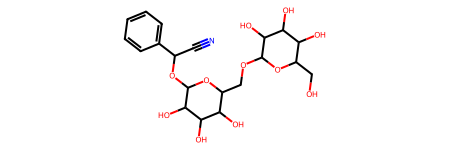

In [7]:
all_data[0].mol # show chemical structure with object .mol

In [8]:
print('name:', all_data[0].name, 'log S:', all_data[0].y)

name: OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O log S: [-0.77]


### use `data.make_split_indices()` to divide all data into train, validation, test sets

https://chemprop.readthedocs.io/en/main/tutorial/python/data/splitting.html

Note that `data.make_split_indices()` puts training (or validation or test) data into a list of several replicates (by default only 1 replica). So we should use index 0 to access the first original copy. e.g. `train_data[0]`. 

In [9]:
mols = [d.mol for d in all_data]  # RDkit Mol objects are use for structure based splits
train_indices, val_indices, test_indices = data.make_split_indices(mols, "random", (0.8, 0.1, 0.1))  # unpack the tuple into three separate lists
train_data, val_data, test_data = data.split_data_by_indices(all_data, train_indices, val_indices, test_indices)
print(len(train_data[0]), len(val_data[0]), len(test_data[0]))

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)


400 50 50


### use `featurizers....` to create a feature vector for each molecule

The simplest featurizer, `SimpleMoleculeMolGraphFeaturizer()`, converts a `mol` to atom and bond type multi-hot vectors, returns a molecular graph `MolGraph` .

https://chemprop.readthedocs.io/en/main/tutorial/python/featurizers/molgraph_molecule_featurizer.html

`dset = data.MoleculeDataset()` makes a dataset using `MoleculeDatapoint` 's; 

`dset.data` is a list with length equal to the number of datapoints.

`dset.names` is a list of smiles strings

`dset.Y` is a list of y values, e.g. log S

When indexed, `dset[ ]` returns a `MolGraph` with atom and bond features, accessed by attribute `dset[].mg`. The MolGraphs are generated as needed by default. 

https://chemprop.readthedocs.io/en/main/tutorial/python/data/datasets.html

In [10]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer() # define the featurizer you want to use
train_dset = data.MoleculeDataset(train_data[0], featurizer)

print(len(train_dset.data))

print('MoleculeDataPoint:', train_dset.data[0]) # show the first datapoint

print('SMILES string:', train_dset.names[0])

print('y value:', train_dset.Y[0])

print('molecular graph feature vector:')
print(train_dset[0])

400
MoleculeDataPoint: MoleculeDatapoint(mol=<rdkit.Chem.rdchem.Mol object at 0x79bc3dd64f20>, y=array([-5.35]), weight=1.0, gt_mask=None, lt_mask=None, x_d=None, x_phase=None, name='CC(=O)OC3(CCC4C2C=C(C)C1=CC(=O)CCC1(C)C2CCC34C)C(C)=O', V_f=None, E_f=None, V_d=None)
SMILES string: CC(=O)OC3(CCC4C2C=C(C)C1=CC(=O)CCC1(C)C2CCC34C)C(C)=O
y value: [-5.35]
molecular graph feature vector:
Datum(mg=MolGraph(V=array([[0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.15999],
       ...,
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.15999]],
      shape=(28, 72), dtype=float32), E=array([[0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
  

### scaling (normalizing) target values (y values)

- define scaler using training data

- apply scaler to validation data

- do not apply scaler to test data

https://chemprop.readthedocs.io/en/main/tutorial/python/scaling.html

In [11]:
scaler = train_dset.normalize_targets()

val_dset = data.MoleculeDataset(val_data[0], featurizer)
val_dset.normalize_targets(scaler)

test_dset = data.MoleculeDataset(test_data[0], featurizer)

# Note that y values in train_dset and val_dset are scaled; but not scaled in test_dset 

### define data loaders

https://chemprop.readthedocs.io/en/latest/tutorial/python/data/dataloaders.html

In [12]:
num_workers = 0 # number of workers for dataloader. 0 means using main process for data loading

train_loader = data.build_dataloader(train_dset, num_workers=num_workers)
val_loader = data.build_dataloader(val_dset, num_workers=num_workers, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=num_workers, shuffle=False)

### 3.2 Define Message-Passing Neural Network (MPNN) to perform regression

In [13]:
mp = nn.BondMessagePassing()
agg = nn.MeanAggregation()
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler) # output from FFN will be unscaled to original range
ffn = nn.RegressionFFN(output_transform=output_transform)
batch_norm = True
metric_list = [nn.metrics.RMSE(), nn.metrics.MAE()] # Only the first metric is used for training and early stopping


In [14]:
mpnn = models.MPNN(mp, agg, ffn, batch_norm, metric_list)
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=300, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): Identity()
  (metrics): ModuleList(
    (0): RMSE(task_weights=[[1.0]])
    (1): MAE

### 3.3 Setup trainer using `lightning`

In [15]:
from lightning import pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint

In [16]:
# Configure model checkpointing
checkpointing = ModelCheckpoint(
    "checkpoints",  # Directory where model checkpoints will be saved
    "best-{epoch}-{val_loss:.2f}",  # Filename format for checkpoints, including epoch and validation loss
    "val_loss",  # Metric used to select the best checkpoint (based on validation loss)
    mode="min",  # Save the checkpoint with the lowest validation loss (minimization objective)
    save_last=True,  # Always save the most recent checkpoint, even if it's not the best
)


trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=True, # Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.
    enable_progress_bar=True,
    accelerator="auto",
    devices=1,
    max_epochs=20, # number of epochs to train for
    callbacks=[checkpointing], # Use the configured checkpoint callback
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 3.4 training 

In [17]:
trainer.fit(mpnn, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/tylerdell2/PythonProjects/mls/notebooks/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
/home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-pac

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  227 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ BatchNorm1d        │    600 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 90.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 318 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 318 K                                                                                                
Total estimated model params size (MB): 1.276                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_c
onnector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the
value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=20` reached.


### 3.5 performance on test dataset

In [18]:
results = trainer.test(dataloaders=test_loader, weights_only=False)  # weights_only=False is only required with pytorch lightning version 2.6.0 or newer


/home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:149: `.test(ckpt_path=None)` was called without a model. The best model of the previous `fit` call will be used. You can pass `.test(ckpt_path='best')` to use the best model or `.test(ckpt_path='last')` to use the last model. If you pass a value, this warning will be silenced.
Restoring states from the checkpoint path at /home/tylerdell2/PythonProjects/mls/notebooks/checkpoints/best-epoch=19-val_loss=0.08.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /home/tylerdell2/PythonProjects/mls/notebooks/checkpoints/best-epoch=19-val_loss=0.08.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/mae          │    0.6252877712249756     │
│         test/rmse         │    0.8839902281761169     │
└───────────────────────────┴───────────────────────────┘

/home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


### 3.6 prediction: output y values


In [19]:
# load a trained model from checkpoint file
checkpoint_path= 'checkpoints/best-epoch=19-val_loss=0.08.ckpt'
mpnn = models.MPNN.load_from_checkpoint(checkpoint_path)
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=300, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): Identity()
  (metrics): ModuleList(
    (0): RMSE(task_weights=[[1.0]])
    (1): MAE

In [20]:
train_pred_loader = data.build_dataloader(train_dset, num_workers=num_workers,shuffle=False) # turn off shuffle to make comparison

train_preds = trainer.predict(mpnn, train_pred_loader)
val_preds = trainer.predict(mpnn, val_loader)
test_preds = trainer.predict(mpnn, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/tylerdell2/miniconda3/envs/.chemprop/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

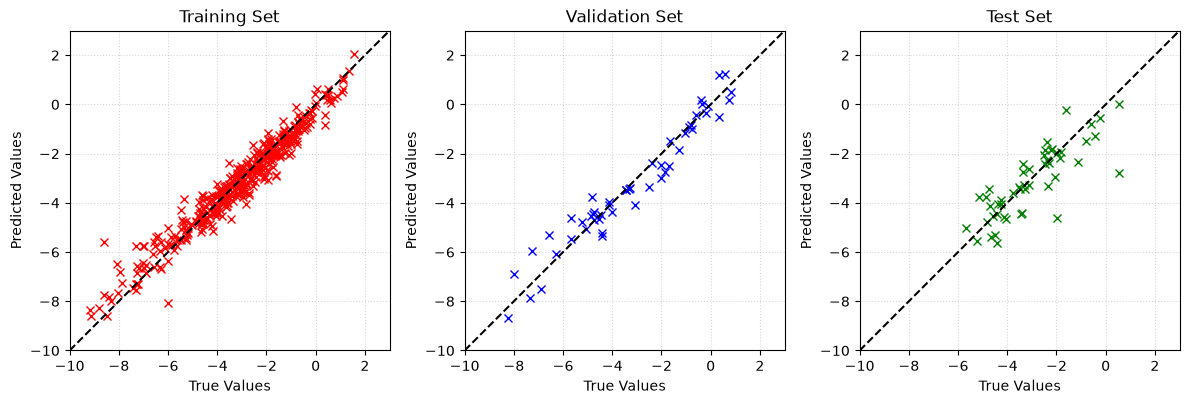

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Training set
y_train = np.concatenate([molpoint.y for molpoint in train_data[0][:]])
pred_train = torch.cat(train_preds, dim=0).flatten().detach().cpu().numpy()

axes[0].plot(y_train, pred_train, 'rx')
axes[0].plot([-10, 3], [-10, 3], 'k--')
axes[0].set_title('Training Set')

# Validation set
y_val = np.concatenate([molpoint.y for molpoint in val_data[0][:]])
pred_val = torch.cat(val_preds, dim=0).flatten().detach().cpu().numpy()

axes[1].plot(y_val, pred_val, 'bx')
axes[1].plot([-10, 3], [-10, 3], 'k--')
axes[1].set_title('Validation Set')

# Test set
y_test = test_dset.Y.reshape(-1)
pred_test = torch.cat(test_preds, dim=0).flatten().detach().cpu().numpy()

axes[2].plot(y_test, pred_test, 'gx')
axes[2].plot([-10, 3], [-10, 3], 'k--')
axes[2].set_title('Test Set')

# Formatting
for ax in axes:
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')
    ax.set_xlim(-10, 3)
    ax.set_ylim(-10, 3)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 3.7 extract molecular fingerprint latent representations 

https://chemprop.readthedocs.io/en/latest/mpnn_fingerprints.html

`models.MPNN.encoding(inputs : BatchMolGraph, i : int)` calculate the i-th hidden representation.

- `i = 0`
- `i = 1`
- `i = -1`

In [25]:
with torch.no_grad():
    fingerprints = [
        mpnn.encoding(batch.bmg, batch.V_d, batch.X_d, i=0)
        for batch in test_loader
    ]
    fingerprints = torch.cat(fingerprints, 0)

fingerprints.shape

torch.Size([50, 300])

(array([ 3., 19., 32., 26., 90., 17., 18., 17., 55., 23.]),
 array([-0.89640963, -0.70624304, -0.51607639, -0.32590973, -0.13574314,
         0.05442345,  0.24459016,  0.43475676,  0.62492335,  0.81508994,
         1.00525665]),
 <BarContainer object of 10 artists>)

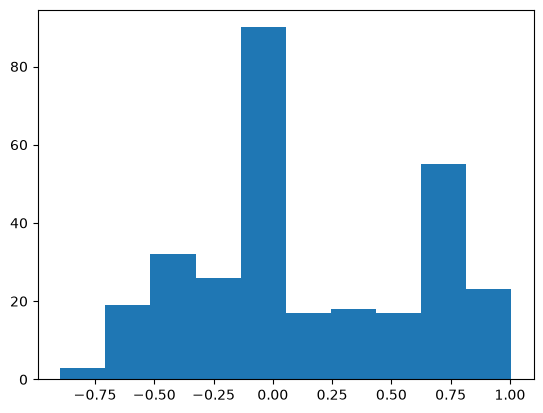

In [33]:
plt.hist(fingerprints[0])

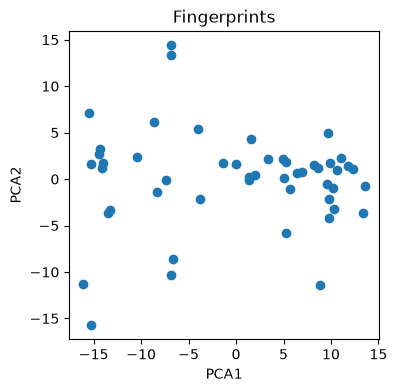

In [38]:
fingerprints = fingerprints.detach()

pca = PCA(n_components=2)

principalComponents = pca.fit_transform(fingerprints)

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(1, 1, 1)
ax.set_title("Fingerprints")
ax.set_xlabel('PCA1'); ax.set_ylabel('PCA2')

ax.scatter(principalComponents[:, 0], principalComponents[:, 1])
plt.show()

In [26]:
with torch.no_grad():
    encodings = [
        mpnn.encoding(batch.bmg, batch.V_d, batch.X_d, i=1)
        for batch in test_loader
    ]
    encodings = torch.cat(encodings, 0)

encodings.shape

torch.Size([50, 300])

(array([ 1.,  6., 24., 42., 65., 63., 51., 28., 13.,  7.]),
 array([-0.90381706, -0.72120333, -0.5385896 , -0.35597587, -0.17336214,
         0.00925159,  0.19186532,  0.37447906,  0.55709279,  0.73970652,
         0.92232025]),
 <BarContainer object of 10 artists>)

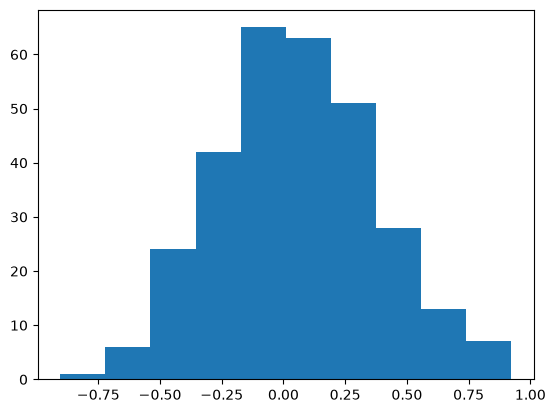

In [34]:
plt.hist(encodings[0])

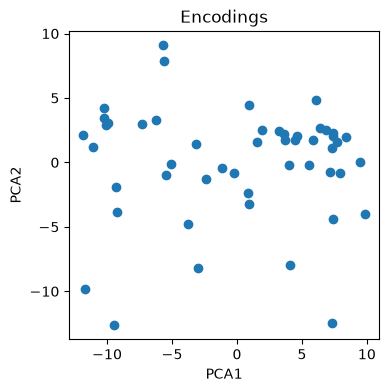

In [37]:
encodings = encodings.detach()

pca = PCA(n_components=2)

principalComponents = pca.fit_transform(encodings)

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(1, 1, 1)
ax.set_title("Encodings")
ax.set_xlabel('PCA1'); ax.set_ylabel('PCA2')

ax.scatter(principalComponents[:, 0], principalComponents[:, 1])
plt.show()

## The End